# Supplementary Figure S6: `s06_hyperparam_selection`

This notebook rebuilds the figure step by step from its script, `figures/supplementary/sup_hyperparam_selection.py`. Every code cell below is a verbatim slice of that file, in the order the file defines it: first the imports and configuration, then each helper function with a short explanation, then the body of `main()` laid out as the assembly of the panels, and finally the rendered figure with its caption. Run the cells top to bottom; in the reference environment the PNG written at the end is identical to the submitted manuscript file (see docs/REPRODUCIBILITY.md).

Supplementary Figure S6 documents how the synthesis regularization was chosen for each of the 250 model-site pairs (25 sites by 10 models). Rather than hand-tuning, an automated search walked a five-rung ladder of (augmentation-noise, spectral-decay alpha) regimes and stopped at the first rung whose synthesis success rate exceeded 0.95. Panels a and b show where every model-site landed on the ladder, colored first by animal and then by model; panel c summarizes each model's mean rung; panel d shows the success rate actually achieved at the selected rung. The data are a single cached table of the selection outcome per model-site, `sup_hyperparam_hp_tuning_selected.csv`, rebuilt from the production logs.

## What the script says about itself

Supp Fig (hyperparam_selection) - automated synthesis-regularization selection.

An automated procedure identified a suitable regularization regime independently for each of the 250 model-site combinations. It stepped up a ladder of (augmentation-noise, spectral-decay alpha) regimes ordered least-to-most aggressive and stopped at the first rung whose synthesis success rate exceeded 0.95. This is the SELECTION-method figure (a companion supplementary figure shows the robust advantage survives regressing the selected regime out).

- **(a)** The 5-rung ladder and the selected regime for all 250 model-sites (dots dodged on each rung, coloured by animal) - most sites land on the two least-aggressive rungs.
- **(b)** Per-model mean selected rung (0 = least aggressive), ordered - models differ modestly in the aggressiveness they require.
- **(c)** Distribution of the achieved success rate at the selected rung; the procedure targets > 0.95 and returns the best-available regime, so most (but not all) sites clear the 0.95 line.

Number stamped from the manifest. Self-contained: reads only the cache preprocessed_data/sup_hyperparam_hp_tuning_selected.csv (rebuilt from the production-log recovery json by scripts/preprocessing/build_hp_tuning_cache.py).

## 1. Environment

A few lines that are not in the script: they make the notebook render exactly like the command-line harness does (single-threaded BLAS, the Agg backend with matplotlib defaults, the repository on the import path) and check that the preprocessed data are present.

In [1]:
import os, sys
from pathlib import Path

# Keep BLAS single-threaded: multithreaded OpenMP together with torch can kill the kernel on macOS.
for _v in ('OMP_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'MKL_NUM_THREADS', 'VECLIB_MAXIMUM_THREADS'):
    os.environ.setdefault(_v, '1')
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')

# Render with the Agg backend and matplotlib's defaults, exactly like the figure scripts;
# Jupyter's inline backend would otherwise change dpi and bounding boxes.
os.environ['MPLBACKEND'] = 'Agg'
import matplotlib; matplotlib.use('Agg'); matplotlib.rcdefaults()

# Work from the repository root whether the notebook is opened there or in notebooks/figures/.
REPO = Path.cwd() if (Path.cwd() / 'pnc').exists() else Path.cwd().parents[1]
sys.path.insert(0, str(REPO))
from pnc import paths

# The figures read the preprocessed caches only; this raises a clear message if they are missing.
paths.require(paths.preprocessed_data() / 'brain_red.pkl')   # python data/download_data.py --tier preprocessed
OUT_DIR = paths.output_dir() / 'figures'
OUT_DIR.mkdir(parents=True, exist_ok=True)

## 2. Imports, style and configuration

The script starts by importing the study configuration and figure style from `pnc` (colours, model names, the publication rcParams) and the cache loader, then fixes the constants that the panels share: which sites and models are shown, layout sizes, colour choices, and where the inputs live. `apply_figure_style()` is what makes every figure in the paper look the same.

`LADDER` lists the five (noise, alpha) pairs in rung order, with rung 0 the least aggressive, and `STOP` is the 0.95 success-rate target. `MONKEY_REGION` and `MONKEY_NAME` supply the legend labels, and `SHORT` relabels the untrained AlexNet as "Untrained". Changing `STOP` only moves the reference line and the reported fraction in panel d; it does not rerun the selection.

In [2]:
import os

import numpy as np

import pandas as pd

import matplotlib

matplotlib.use('Agg')

import matplotlib.pyplot as plt

from matplotlib.gridspec import GridSpec

from matplotlib.lines import Line2D

from pnc import paths

from pnc.manifest import fig as _fig, output_name

from pnc.utils import (apply_figure_style, FONT_FAMILY, MM, WIDTH_2COL_MM, FIG_FACECOLOR, save_fig,
                       MODEL_COLORS, MODEL_SHORT_NAMES, ROBUST_MODELS, MONKEY_COLORS,
                       get_model_color, MODEL_ORDER)

apply_figure_style()

_M = _fig('hyperparam_selection'); STEM = output_name('hyperparam_selection')



CSV = os.path.join(str(paths.preprocessed_data()), 'sup_hyperparam_hp_tuning_selected.csv')

SHORT = dict(MODEL_SHORT_NAMES); SHORT['AlexNet_training_seed_01'] = 'Untrained'   # display relabel



ROBUST = set(ROBUST_MODELS)

MONKEYS = ['red', 'paul', 'venus', 'leap', 'three0']

MONKEY_REGION = {'red': 'aIT', 'paul': 'cIT', 'venus': 'V3/V4', 'leap': 'STS', 'three0': 'STS'}

MONKEY_NAME = {'red': 'Monkey R', 'paul': 'Monkey P', 'venus': 'Monkey V',
               'leap': 'Monkey L', 'three0': 'Monkey T'}

# The regularization ladder: (augmentation noise, spectral-decay alpha), least -> most aggressive
# (rung 0 = least aggressive = first visited by the search).
LADDER = [(0.05, 1.2), (0.10, 1.5), (0.15, 2.0), (0.25, 2.4), (0.30, 2.5)]

STOP = 0.95                                          # success-rate stopping threshold

FS_LET, FS_TITLE, FS_AX, FS_TICK, FS_ANNOT = 8, 7, 6.5, 5.5, 5.5

## 3. The building blocks

Each function below is one component of the figure: loading and shaping a cache, computing a statistic, or drawing one panel into an axes it is handed. They are defined here exactly as in the script and used by the assembly in the last section; read them in order, the assembly calls them in roughly the same order.

`load` attaches a rung index to each row, then three panel functions draw the figure: `panel_a` draws the ladder (called twice with different colorings), `panel_b` the per-model bars and `panel_c` the success-rate histogram. Note that the code's `panel_b` and `panel_c` correspond to caption panels C and D.

### `load()`

── data (self-contained cache) ──────────────────────────────────────────────

Reads the cache and maps each row's (noise, decay) pair onto its `LADDER` index, stored as a new `rung` column. Values are rounded to two decimals before lookup so float noise in the CSV cannot break the match.

In [3]:
# ── data (self-contained cache) ──────────────────────────────────────────────
def load():
    df = pd.read_csv(paths.require(CSV, hint='python scripts/preprocessing/build_hp_tuning_cache.py'))
    rung = {(round(n, 2), round(d, 2)): i for i, (n, d) in enumerate(LADDER)}
    df['rung'] = df.apply(lambda r: rung[(round(r.noise, 2), round(r.decay, 2))], axis=1)
    return df

### `spread_ties(vals, xcenter, halfwidth)`

Evenly dodge points that share a discrete value so none overlap.

A helper that dodges points sharing a discrete value so they do not overlap. It is defined but not used by the current panels, which dodge with a fixed linear spread instead.

In [4]:
def spread_ties(vals, xcenter, halfwidth):
    """Evenly dodge points that share a discrete value so none overlap."""
    from collections import defaultdict
    xs = np.full(len(vals), float(xcenter))
    groups = defaultdict(list)
    for i, v in enumerate(vals):
        groups[round(float(v), 6)].append(i)
    for _, idxs in groups.items():
        offs = [0.0] if len(idxs) == 1 else np.linspace(-halfwidth, halfwidth, len(idxs))
        for k, i in enumerate(idxs):
            xs[i] = xcenter + offs[k]
    return xs

### `panel_a(ax, df, color_by='monkey', legend=True, show_yaxis=True)`

── panel a: the ladder + selected rung for all 250 sites ─────────────────────

Draws the ladder as five horizontal bands, one per rung, with every model-site on that rung spread evenly across the band and given a small vertical jitter; the count per rung is printed at the right. With `color_by='monkey'` dots take the animal's color; with `color_by='model'` they are first sorted by `MODEL_ORDER` and colored by model, so the model colors form contiguous runs. The y-axis is inverted so rung 0 sits on top, and `show_yaxis=False` lets the second copy share the first copy's tick labels.

In [5]:
# ── panel a: the ladder + selected rung for all 250 sites ─────────────────────
def panel_a(ax, df, color_by='monkey', legend=True, show_yaxis=True):
    rng = np.random.default_rng(7)
    for r in range(len(LADDER)):
        sub = df[df.rung == r]
        if color_by == 'model':                          # group the dodge by model (panel a keeps its animal grouping)
            om = {m: i for i, m in enumerate(MODEL_ORDER)}
            sub = sub.iloc[np.argsort([om.get(m, 99) for m in sub['model']], kind='stable')]
        n = len(sub)
        # dodge across the rung width; jitter vertically inside the rung band
        xs = np.linspace(-0.36, 0.36, n) if n > 1 else np.array([0.0])
        xs = xs + rng.uniform(-0.006, 0.006, n)
        ys = r + rng.uniform(-0.16, 0.16, n)
        cols = ([MONKEY_COLORS[mk] for mk in sub.monkey] if color_by == 'monkey'
                else [get_model_color(m) for m in sub.model])
        ax.scatter(xs, ys, s=5.0, c=cols, alpha=0.85, edgecolors='white',
                   linewidths=0.15, zorder=4)
        ax.text(0.52, r, f'n = {n}', ha='left', va='center', fontsize=FS_ANNOT,
                fontfamily=FONT_FAMILY, color='#333', zorder=6)
    ax.set_yticks(range(len(LADDER)))
    ax.set_yticklabels([f'{i}  ({n:g}, {a:g})' for i, (n, a) in enumerate(LADDER)]
                       if show_yaxis else [], fontsize=FS_TICK)
    ax.set_ylim(-0.55, len(LADDER) - 0.4)
    ax.set_xlim(-0.6, 0.95)
    ax.invert_yaxis()                                # rung 0 (first visited) on top
    if show_yaxis:
        ax.set_ylabel('Ladder rung  (noise, ' + r'$\alpha$' + ')', fontsize=FS_AX)
    ax.set_xticks([])
    ax.tick_params(axis='y', labelsize=FS_TICK, length=0)
    ax.text(0.52, -0.42, 'least aggressive', ha='left', va='center', fontsize=FS_ANNOT,
            color='#999', fontfamily=FONT_FAMILY)
    ax.text(0.52, len(LADDER) - 0.62, 'most aggressive', ha='left', va='center',
            fontsize=FS_ANNOT, color='#999', fontfamily=FONT_FAMILY)
    if legend:
        if color_by == 'monkey':
            leg = [Line2D([0], [0], marker='o', ls='', mfc=MONKEY_COLORS[mk], mec='white', mew=0.2,
                          ms=2.6, label=f'{MONKEY_NAME[mk]} ({MONKEY_REGION[mk]})') for mk in MONKEYS]
            ncol = 3
        else:
            leg = [Line2D([0], [0], marker='o', ls='', mfc=get_model_color(m), mec='white', mew=0.2,
                          ms=2.6, label=SHORT[m]) for m in MODEL_ORDER]
            ncol = 2
        ax.legend(handles=leg, fontsize=FS_ANNOT - 0.5, frameon=False,
                  loc='upper center', bbox_to_anchor=(0.5, -0.03), ncol=ncol,
                  handletextpad=0.2, columnspacing=0.7, labelspacing=0.2, borderpad=0.1)

### `panel_b(ax, df)`

── panel b: per-model mean selected rung ─────────────────────────────────────

Mean selected rung per model as bars, sorted ascending and colored by model, with an orange triangle above the two adversarially trained models.

In [6]:
# ── panel b: per-model mean selected rung ─────────────────────────────────────
def panel_b(ax, df):
    means = df.groupby('model').rung.mean()
    order = means.sort_values().index.tolist()
    xs = np.arange(len(order))
    vals = [means[m] for m in order]
    cols = [get_model_color(m) for m in order]
    ax.bar(xs, vals, color=cols, edgecolor='white', linewidth=0.4, zorder=3)
    for m, x in zip(order, xs):
        if m in ROBUST:
            ax.scatter(x, means[m] + 0.055, marker='v', s=8, color='#E1812C',
                       edgecolors='none', zorder=5)
    ax.set_xticks(xs)
    ax.set_xticklabels([SHORT[m] for m in order], rotation=55, ha='right', fontsize=FS_TICK)
    for t, m in zip(ax.get_xticklabels(), order):
        t.set_color(get_model_color(m))
    ax.set_ylabel('Mean selected rung', fontsize=FS_AX)
    ax.set_ylim(0, max(vals) * 1.22)
    ax.tick_params(axis='y', labelsize=FS_TICK)
    ax.legend(handles=[Line2D([0], [0], marker='v', ls='', mfc='#E1812C', mec='none',
                              ms=3.2, label='Adversarially trained')],
              fontsize=FS_ANNOT, frameon=False, loc='upper left',
              handletextpad=0.2, borderpad=0.2)

### `panel_c(ax, df)`

── panel c: success-rate distribution at the selected rung ───────────────────

Histogram of the achieved success rate at the selected rung across all model-sites, with a dashed red line at `STOP`. It returns the fraction of model-sites at or above that target, which is also printed on the panel.

In [7]:
# ── panel c: success-rate distribution at the selected rung ───────────────────
def panel_c(ax, df):
    sr = df.success_rate.values
    ax.hist(sr, bins=np.linspace(0.30, 1.0, 29), color='#3274A1', alpha=0.85,
            edgecolor='white', linewidth=0.3, zorder=3)
    ax.axvline(STOP, color='#E63946', ls='--', lw=1.0, zorder=5)
    ax.text(STOP - 0.012, ax.get_ylim()[1] * 0.98, f'target {STOP:g}', ha='right', va='top',
            fontsize=FS_ANNOT, color='#E63946', fontfamily=FONT_FAMILY, zorder=6)
    frac = np.mean(sr >= STOP)
    ax.set_xlabel('Success rate at selected rung', fontsize=FS_AX)
    ax.set_ylabel('Model-sites', fontsize=FS_AX)
    ax.set_xlim(0.30, 1.02)
    ax.tick_params(labelsize=FS_TICK)
    ax.text(0.03, 0.96, f'{frac*100:.0f}% $\\geq$ {STOP:g}', transform=ax.transAxes,
            ha='left', va='top', fontsize=FS_ANNOT, fontfamily=FONT_FAMILY, color='#222')
    return frac

## 4. Assembling the figure

This is the body of `main()` from the script, laid out step by step: it builds the figure canvas, calls the building blocks to fill each panel, and saves the result with `save_fig`, which trims the white border so the file matches the submitted figure.

A single-row GridSpec of four axes at two-column width, with the two ladder panels given more width than the bar chart and histogram. Panels are drawn left to right, then spines are trimmed and titles and letters are placed against the measured axis positions.

In [8]:
# Inputs of the assembly below (these are the parameters of main() in the script).
out_dir = str(OUT_DIR)

**Step 1**

Loads the table and prints a few diagnostics: the number of model-sites, the number of distinct regimes, the correlation between the noise and decay settings (they move together along the ladder), and the count per rung.

In [9]:
df = load()
r_noise_decay = np.corrcoef(df.noise, df.decay)[0, 1]
n_regimes = df.groupby(['noise', 'decay']).ngroups
print('N site-models:', len(df))
print('distinct regimes:', n_regimes)
print('noise-decay r:', round(r_noise_decay, 3))
print('rung counts:', df.rung.value_counts().sort_index().to_dict())

N site-models: 250
distinct regimes: 5
noise-decay r: 0.976
rung counts: {0: 119, 1: 61, 2: 45, 3: 13, 4: 12}


**Step 2**

Creates the figure and four axes, then draws the ladder twice (by animal, then by model with its y-axis hidden), the per-model bars and the success histogram, keeping the returned fraction for the final printout.

In [10]:
fig = plt.figure(figsize=(WIDTH_2COL_MM * MM, 68 * MM), facecolor=FIG_FACECOLOR)
gs = GridSpec(1, 4, figure=fig, left=0.055, right=0.99, top=0.85, bottom=0.38,
              wspace=0.42, width_ratios=[1.30, 1.30, 1.0, 1.0])
axA = fig.add_subplot(gs[0, 0]); axB = fig.add_subplot(gs[0, 1])
axC = fig.add_subplot(gs[0, 2]); axD = fig.add_subplot(gs[0, 3])
panel_a(axA, df, color_by='monkey', legend=True)                    # a: ladder coloured by animal
panel_a(axB, df, color_by='model', legend=True, show_yaxis=False)   # b: SAME ladder, model colours (shares a's y-axis)
panel_b(axC, df); frac = panel_c(axD, df)             # c/d: former b/c pushed over

**Step 3**

Hides the top and right spines on all four axes.

In [11]:
for ax in (axA, axB, axC, axD):
    for s in ('top', 'right'):
        ax.spines[s].set_visible(False)

**Step 4**

Draws the canvas so axis positions are final, then writes a title above each panel and a bold letter at its top left; panel b's letter is tucked closer because it has no y-axis labels.

In [12]:
titles = ['Selection ladder (250 model-sites)', 'Selection ladder (by model)',
          'Aggressiveness per model', 'Success at selected rung']
fig.canvas.draw()
letter_dx = dict(a=0.052, b=0.018, c=0.045, d=0.045)   # b has no y-axis, so tuck its letter closer
for ax, letter, title in zip((axA, axB, axC, axD), 'abcd', titles):
    bb = ax.get_position()
    fig.text((bb.x0 + bb.x1) / 2, bb.y1 + 0.018, title, ha='center', va='bottom',
             fontsize=FS_TITLE, fontfamily=FONT_FAMILY)
    fig.text(bb.x0 - letter_dx[letter], bb.y1 + 0.075, letter, ha='left', va='top', fontsize=FS_LET,
             fontweight='bold', fontfamily=FONT_FAMILY)

**Step 5**

Saves the figure and prints the fraction of model-sites whose achieved success rate met the 0.95 target.

In [13]:
path = save_fig(fig, os.path.join(out_dir, STEM))
plt.close(fig)
print('Saved ->', path)
print(f'fraction success>= {STOP}: {frac*100:.1f}%')
png = path

Saved -> /private/tmp/claude-501/-Users-jacobprince-KonkLab-Dropbox-Jacob-Prince-Research-Prince-Accentuate-VVS-Manuscript/bca6882d-ec2d-4dbd-beb1-0d67d8b1fcc7/scratchpad/nb_exec_out/figures/s06_hyperparam_selection.png
fraction success>= 0.95: 66.4%


## 5. The figure

`png` now points at the rendered file. A downscaled preview follows (the full-resolution PNG is the file itself, `s06_hyperparam_selection.png` in the output directory).

Most dots sit on the top two rungs of the ladder in panels a and b, and every model spreads across several rungs. In panel d, look at how much of the histogram lies to the right of the dashed line: the procedure returns the best available regime, so a minority of model-sites fall short of the target.

/private/tmp/claude-501/-Users-jacobprince-KonkLab-Dropbox-Jacob-Prince-Research-Prince-Accentuate-VVS-Manuscript/bca6882d-ec2d-4dbd-beb1-0d67d8b1fcc7/scratchpad/nb_exec_out/figures/s06_hyperparam_selection.png


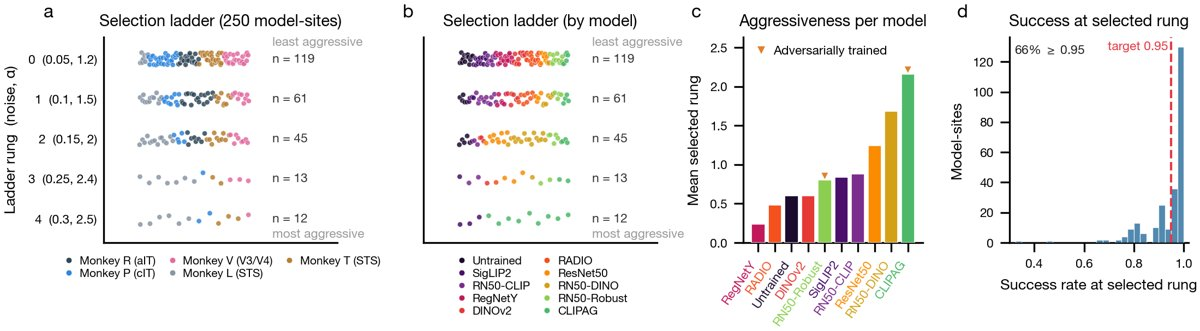

In [14]:
import io
from IPython.display import Image, display
from PIL import Image as PILImage

# A JPEG preview keeps the notebook small; open the PNG for full detail.
print(png)
im = PILImage.open(png).convert("RGB")
im.thumbnail((1200, 1200))
buf = io.BytesIO(); im.save(buf, "JPEG", quality=85, optimize=True)
display(Image(data=buf.getvalue(), format="jpeg", width=900))

**Supplementary Figure S6. Automated synthesis-regularization selection.** An automated procedure selected the synthesis regularization independently for each of the 250 model-site combinations, stepping down a five-rung ladder of (augmentation-noise, spectral-decay $\alpha$) regimes ordered most to least aggressive and stopping at the first rung whose synthesis success rate exceeded $0.95$. (A) The selected rung for all $n = 250$ model-sites ($25$ sites $\times$ $10$ models), dodged within each rung and colored by animal (R/aIT, P/cIT, V/V3/V4, L and T/STS); rung labels give the (noise, $\alpha$) pair, with rung $0$ least aggressive. Most sites land on the two least-aggressive rungs ($n = 119$ and $n = 61$). (B) The same selection ladder recolored by model (legend), showing that every model spreads across the rungs. (C) Per-model mean selected rung ($0 =$ least aggressive), colored by model and ordered ascending; adversarially trained models (orange triangles) are marked. Models differ only modestly in the aggressiveness they require. (D) Distribution of the achieved success rate at the selected rung across the $250$ model-sites; dashed red line marks the $0.95$ target. The procedure returns the best-available regime, so $66%$ of sites clear the $0.95$ line.